# 20.5 換個問法，為什麼仍可能是同一道舊題？


同一張貓照片，換成問數量或問姿勢，仍共享一份畫面。若其中一題用來訓練，另一題當陌生照片測試，模型可能已記熟背景。原圖、裁切與問法應先歸成一個來源家族，再一起分配用途。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

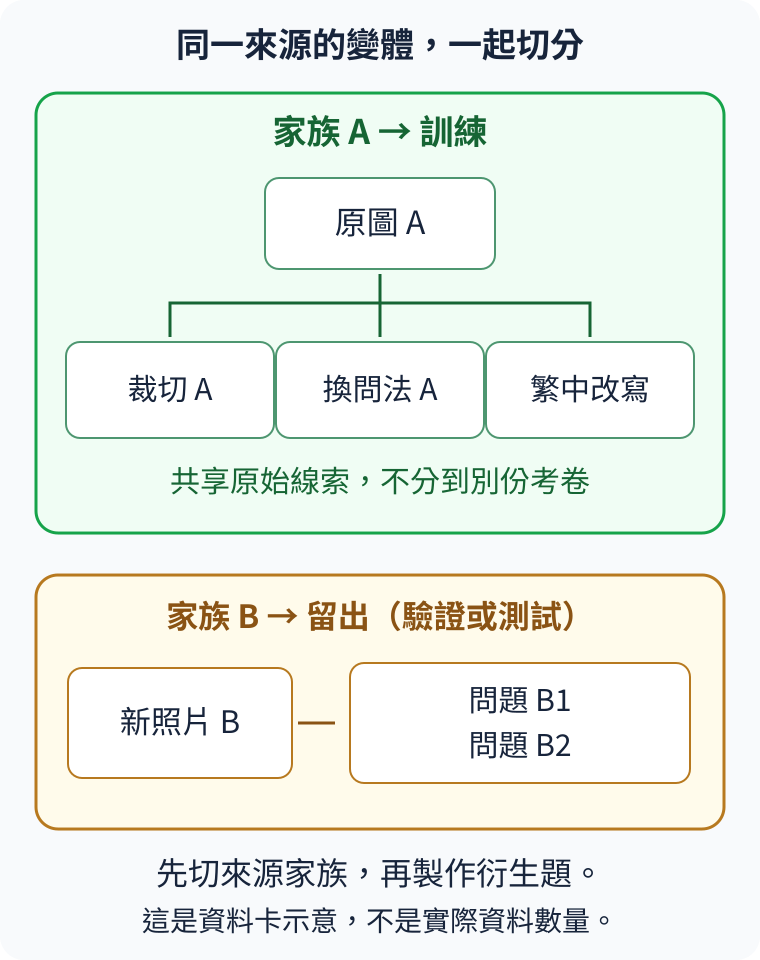

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/natural-v4-family-crops.svg")))

下面用四筆人工記錄，檢查已分到 train／test 的題目是否讓同一家族跨份；程式不會自動重新切分資料。


In [3]:
records = [
    {"family": "貓照片A", "split": "train", "question": "有幾隻貓？"},
    {"family": "貓照片A", "split": "train", "question": "哪隻貓抬起前腳？"},
    {"family": "招牌照片B", "split": "test", "question": "招牌寫什麼？"},
    {"family": "招牌照片B", "split": "test", "question": "有沒有中文字？"},
]
families = {name: {row["family"] for row in records if row["split"] == name} for name in ["train", "test"]}
print("訓練家族", sorted(families["train"]))
print("測試家族", sorted(families["test"]))
print("跨份重疊", sorted(families["train"] & families["test"]))

訓練家族 ['貓照片A']
測試家族 ['招牌照片B']
跨份重疊 []


兩份集合分別含貓照片A與招牌照片B，所以交集為空。把第二筆的 split 改成 test，貓照片A就跨份了，雖然文字不同。修正是讓家族一起走，不能只替它改一個名字。

正式資料還要核對來源ID與實際檔案，避免相同像素換檔名。DOCCI 的公開相似群組表示畫面相近，不等於已確認同一拍攝session；OpenAssistant的共享前文分支則屬同一對話樹。資料有哪種群組，能力聲明就到哪裡。

驗證用來選本課微調版本，最後份定版後才檢查。已公開舊題用來檢查改動後是否仍能完成原先的工作，這叫回歸檢查；它不再算新盲測。本課家族隔離也不能排除上游預訓練曾見過這些公開素材。
